# Resource Contention Example in Python

This notebook demonstrates **resource contention** with a practical and reproducible example.

## What you will learn
- What resource contention means
- Why contention hurts throughput and latency
- How to simulate contention with Python threads
- How to measure waiting time on a shared resource
- How a small design change can reduce contention

## Scenario
Multiple worker threads need to update a shared resource protected by a lock.  
When many threads try to access the lock at the same time, they **contend** for it.

This is a simple model of real systems such as:
- multiple CPU threads updating shared state
- many requests writing to the same database row
- several processes competing for a file or socket
- distributed workers trying to use a single coordinator or queue

Even though this example uses Python threads, the core idea applies broadly to operating systems, databases, distributed systems, and parallel computing.

In [2]:
# Standard library + common scientific tools
import threading
import time
from dataclasses import dataclass, asdict
from statistics import mean
from typing import List

import pandas as pd
import matplotlib.pyplot as plt

# Make notebook output a bit friendlier
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 1. Core idea

A **resource** is something multiple execution units want to use:
- CPU core
- memory region
- lock
- file handle
- database connection
- network port
- GPU
- shared variable

**Resource contention** happens when several threads/processes/tasks want the same resource at the same time.

### Typical symptoms
- lower throughput
- increased waiting time
- worse scalability
- underutilized hardware due to blocking
- unpredictable latency spikes

In this notebook, the shared resource is a **critical section** protected by a `threading.Lock`.

In [3]:
@dataclass
class ExperimentResult:
    threads: int
    iterations_per_thread: int
    non_critical_work_s: float
    critical_work_s: float
    total_operations: int
    elapsed_s: float
    throughput_ops_per_s: float
    avg_wait_for_lock_ms: float
    max_wait_for_lock_ms: float

def run_contention_experiment(
    num_threads: int,
    iterations_per_thread: int,
    non_critical_work_s: float,
    critical_work_s: float,
) -> ExperimentResult:
    """
    Simulate threads competing for a single lock-protected shared resource.

    Parameters
    ----------
    num_threads : int
        Number of worker threads.
    iterations_per_thread : int
        How many times each thread tries to use the shared resource.
    non_critical_work_s : float
        Simulated work outside the lock. This does not block other threads.
    critical_work_s : float
        Simulated work inside the lock. This increases contention.

    Returns
    -------
    ExperimentResult
        Summary metrics for the whole run.
    """

    lock = threading.Lock()
    shared_counter = 0
    wait_times = []

    def worker():
        nonlocal shared_counter

        for _ in range(iterations_per_thread):
            # Simulate useful work that does NOT require the shared resource
            if non_critical_work_s > 0:
                time.sleep(non_critical_work_s)

            # Measure how long this thread waits before entering the critical section
            t0 = time.perf_counter()
            with lock:
                t1 = time.perf_counter()
                wait_times.append(t1 - t0)

                # Simulate time spent using the shared resource
                if critical_work_s > 0:
                    time.sleep(critical_work_s)

                # Shared state update
                shared_counter += 1

    threads = [threading.Thread(target=worker) for _ in range(num_threads)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    end = time.perf_counter()

    elapsed = end - start
    total_ops = shared_counter
    throughput = total_ops / elapsed if elapsed > 0 else float("nan")

    return ExperimentResult(
        threads=num_threads,
        iterations_per_thread=iterations_per_thread,
        non_critical_work_s=non_critical_work_s,
        critical_work_s=critical_work_s,
        total_operations=total_ops,
        elapsed_s=elapsed,
        throughput_ops_per_s=throughput,
        avg_wait_for_lock_ms=mean(wait_times) * 1000 if wait_times else 0.0,
        max_wait_for_lock_ms=max(wait_times) * 1000 if wait_times else 0.0,
    )

## 2. First experiment: low contention vs high contention

We will compare two cases:

### Case A: Low contention
- little time inside the lock
- more work outside the lock

### Case B: High contention
- more time inside the lock
- threads spend longer holding the shared resource

This should make waiting times larger and reduce scalability.

In [4]:
# Case A: low contention
low_contention = run_contention_experiment(
    num_threads=8,
    iterations_per_thread=40,
    non_critical_work_s=0.003,
    critical_work_s=0.0005,
)

# Case B: high contention
high_contention = run_contention_experiment(
    num_threads=8,
    iterations_per_thread=40,
    non_critical_work_s=0.0005,
    critical_work_s=0.003,
)

comparison_df = pd.DataFrame([asdict(low_contention), asdict(high_contention)], index=["Low contention", "High contention"])
comparison_df

,threads,iterations_per_thread,non_critical_work_s,critical_work_s,total_operations,elapsed_s,throughput_ops_per_s,avg_wait_for_lock_ms,max_wait_for_lock_ms
Low contention,8,40,0.0030,0.0005,320,0.221226,1446.482139,1.136042,7.842000
High contention,8,40,0.0005,0.0030,320,1.199241,266.835533,25.259077,26.164292


### Interpretation

Look especially at:
- `throughput_ops_per_s`
- `avg_wait_for_lock_ms`
- `max_wait_for_lock_ms`

You should observe that when the time spent **inside** the critical section grows:
- waiting time increases
- throughput stops improving
- more threads spend their time blocked rather than doing useful work

## 3. Scaling study

Now we vary the number of threads and observe how the system scales.

A well-scaling parallel program should get faster as threads increase.  
Under heavy contention, adding more threads may produce only small gains or even make performance worse.

In [5]:
def scaling_study(
    thread_counts,
    iterations_per_thread=30,
    non_critical_work_s=0.001,
    critical_work_s=0.002,
):
    results = []
    for n in thread_counts:
        result = run_contention_experiment(
            num_threads=n,
            iterations_per_thread=iterations_per_thread,
            non_critical_work_s=non_critical_work_s,
            critical_work_s=critical_work_s,
        )
        results.append(asdict(result))
    return pd.DataFrame(results)

thread_counts = [1, 2, 4, 8, 12, 16]
df_scaling = scaling_study(
    thread_counts=thread_counts,
    iterations_per_thread=30,
    non_critical_work_s=0.001,
    critical_work_s=0.002,
)

df_scaling

,threads,iterations_per_thread,non_critical_work_s,critical_work_s,total_operations,elapsed_s,throughput_ops_per_s,avg_wait_for_lock_ms,max_wait_for_lock_ms
0,1,30,0.001,0.002,30,0.113366,264.630676,0.002092,0.007875
1,2,30,0.001,0.002,60,0.152632,393.102472,1.259438,2.390542
2,4,30,0.001,0.002,120,0.303604,395.252035,6.212039,6.818042
3,8,30,0.001,0.002,240,0.603711,397.541071,16.045938,16.749875
4,12,30,0.001,0.002,360,0.913934,393.901691,26.186110,30.782750
5,16,30,0.001,0.002,480,1.211755,396.119814,35.964160,37.254000


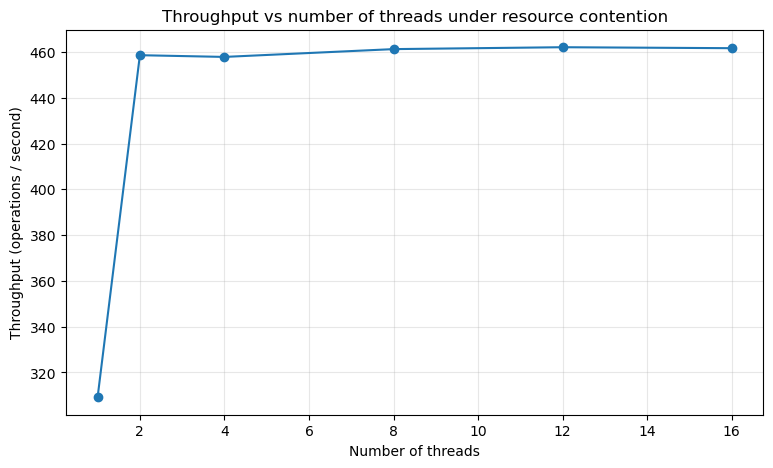

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(df_scaling["threads"], df_scaling["throughput_ops_per_s"], marker="o")
plt.xlabel("Number of threads")
plt.ylabel("Throughput (operations / second)")
plt.title("Throughput vs number of threads under resource contention")
plt.grid(True, alpha=0.3)
plt.show()

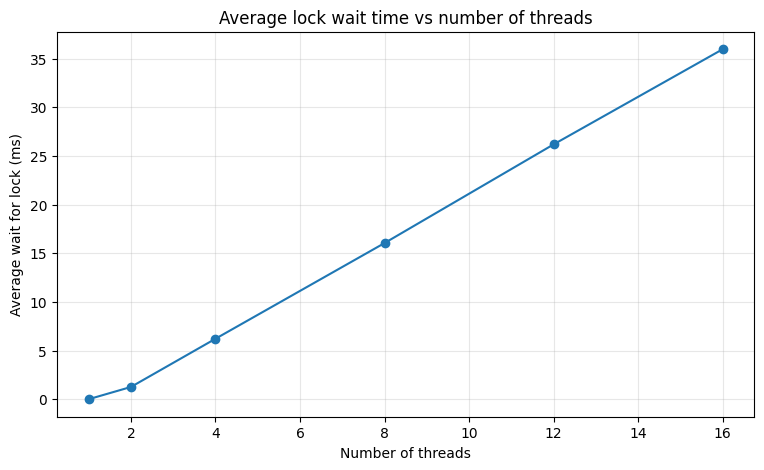

In [6]:
plt.figure(figsize=(9, 5))
plt.plot(df_scaling["threads"], df_scaling["avg_wait_for_lock_ms"], marker="o")
plt.xlabel("Number of threads")
plt.ylabel("Average wait for lock (ms)")
plt.title("Average lock wait time vs number of threads")
plt.grid(True, alpha=0.3)
plt.show()

### Discussion

The two plots usually show an important lesson:

- **Average wait time** grows with more threads
- **Throughput** eventually flattens because the lock becomes the bottleneck

This is the classic signature of contention around a shared resource.

## 4. Why this happens

Suppose the critical section is protected by one global lock.

Only **one thread** can hold that lock at a time.  
Therefore:

- if 10 threads want the lock, 1 thread works and the others wait
- increasing thread count increases competition
- the lock serializes part of the program

This limits parallelism.

This is closely related to **Amdahl's Law**:
> the serial part of a program limits the speedup achievable by parallel execution

## 5. Reducing contention with batching

A common optimization is to reduce how often threads access the shared resource.

Instead of acquiring the lock for every single increment, each thread can:
1. accumulate work locally
2. acquire the lock less frequently
3. apply updates in batches

This often improves throughput because:
- fewer lock acquisitions occur
- less time is spent waiting
- the shared resource is touched less often

In [9]:
def run_batched_experiment(
    num_threads: int,
    iterations_per_thread: int,
    batch_size: int,
    non_critical_work_s: float,
    critical_work_s_per_batch: float,
):
    lock = threading.Lock()
    shared_counter = 0
    wait_times = []

    def worker():
        nonlocal shared_counter
        local_count = 0

        for _ in range(iterations_per_thread):
            if non_critical_work_s > 0:
                time.sleep(non_critical_work_s)

            local_count += 1

            if local_count >= batch_size:
                t0 = time.perf_counter()
                with lock:
                    t1 = time.perf_counter()
                    wait_times.append(t1 - t0)

                    if critical_work_s_per_batch > 0:
                        time.sleep(critical_work_s_per_batch)

                    shared_counter += local_count
                    local_count = 0

        # Flush leftover local work
        if local_count > 0:
            t0 = time.perf_counter()
            with lock:
                t1 = time.perf_counter()
                wait_times.append(t1 - t0)

                if critical_work_s_per_batch > 0:
                    time.sleep(critical_work_s_per_batch)

                shared_counter += local_count

    threads = [threading.Thread(target=worker) for _ in range(num_threads)]

    start = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    end = time.perf_counter()

    elapsed = end - start
    total_ops = shared_counter
    throughput = total_ops / elapsed if elapsed > 0 else float("nan")

    return {
        "threads": num_threads,
        "iterations_per_thread": iterations_per_thread,
        "batch_size": batch_size,
        "total_operations": total_ops,
        "elapsed_s": elapsed,
        "throughput_ops_per_s": throughput,
        "avg_wait_for_lock_ms": mean(wait_times) * 1000 if wait_times else 0.0,
        "max_wait_for_lock_ms": max(wait_times) * 1000 if wait_times else 0.0,
    }

baseline = run_contention_experiment(
    num_threads=12,
    iterations_per_thread=60,
    non_critical_work_s=0.0008,
    critical_work_s=0.0015,
)

batched = run_batched_experiment(
    num_threads=12,
    iterations_per_thread=60,
    batch_size=10,
    non_critical_work_s=0.0008,
    critical_work_s_per_batch=0.0015,
)

pd.DataFrame([asdict(baseline), batched], index=["Baseline: lock every update", "Optimized: batched updates"])

,threads,iterations_per_thread,non_critical_work_s,critical_work_s,total_operations,elapsed_s,throughput_ops_per_s,avg_wait_for_lock_ms,max_wait_for_lock_ms,batch_size
Baseline: lock every update,12,60,0.0008,0.0015,720,1.199233,600.383678,17.245254,17.660817,NaN
Optimized: batched updates,12,60,NaN,NaN,720,0.128235,5614.703467,8.984169,17.015891,10.0


### Expected observation

The batched version often:
- increases throughput
- reduces average lock waiting time
- reduces pressure on the shared resource

This is a simple but important systems idea:

> **Use local work where possible, and minimize time spent on shared resources.**

## 6. Real-world analogies

This toy example maps to many practical scenarios:

### Database contention
Many transactions update the same row or table-level lock.

### File-system contention
Many processes write to the same file.

### Network bottlenecks
Several services share the same limited connection or port.

### Distributed systems
Many workers compete for a centralized coordinator, metadata service, or queue.

### GPU or accelerator contention
Several jobs try to use the same device at once.

In all of these, the pattern is similar:
- the shared resource becomes a bottleneck
- waiting grows
- scaling becomes poor

## 7. Key takeaways

1. **Resource contention** appears when many workers need the same shared resource.
2. A lock is a simple way to model a contended resource.
3. As the critical section grows, waiting time grows too.
4. Adding more threads does not always improve performance.
5. Reducing lock frequency or lock duration often improves scalability.

## 8. Feel free to try
- Increase `critical_work_s` and observe how the plots change.
- Reduce `non_critical_work_s` to make contention even worse.
- Compare 1 global lock vs multiple locks.
- Replace batching with a queue-based design.
- Try the same idea with `multiprocessing` instead of `threading`.